## 1. One cluster - a single Gaussian distribution

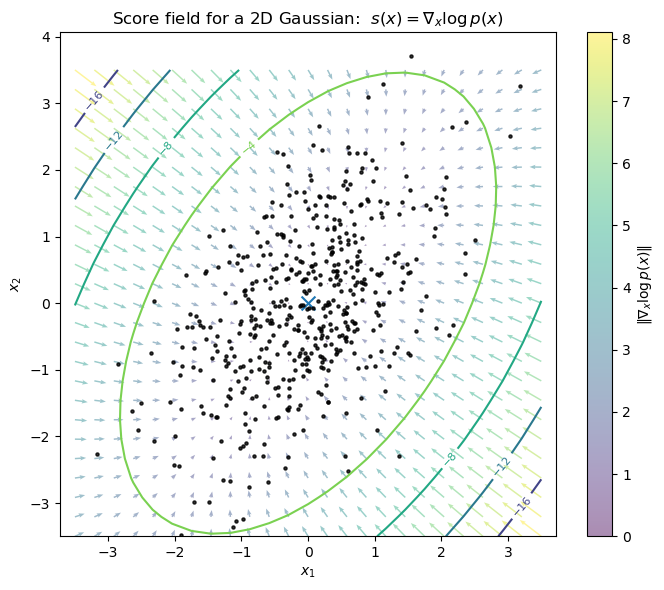

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# 2D Gaussian parameters
mu = np.array([0.0, 0.0])
Sigma = np.array([[1.0, 0.6],
                  [0.6, 1.5]])
Sigma_inv = np.linalg.inv(Sigma)

# Grid
x = np.linspace(-3.5, 3.5, 25)
y = np.linspace(-3.5, 3.5, 25)
X, Y = np.meshgrid(x, y)
grid = np.stack([X, Y], axis=-1)  # (ny, nx, 2)

# Score field: s(x) = -Sigma^{-1}(x - mu)
diff = grid - mu
S = -diff @ Sigma_inv.T
U, V = S[..., 0], S[..., 1]

# Log density up to constant: -0.5 (x-mu)^T Sigma^{-1} (x-mu)
quad = np.einsum('...i,ij,...j->...', diff, Sigma_inv, diff)
logp = -0.5 * quad

plt.figure(figsize=(7, 6))

# Contours of log density (equivalently density contours)
cs = plt.contour(X, Y, logp, levels=5)
plt.clabel(cs, inline=True, fontsize=8)

# color by score magnitude
mag = np.sqrt(U**2 + V**2)

q = plt.quiver(
    X, Y, U, V, mag,              # <-- mag controls the color
    angles='xy', scale_units='xy', scale=20,
    cmap='viridis',               # colorful
    alpha=0.45,                   # lighter / more transparent
    width=0.003,                 # thinner shafts
    headwidth=3.0, headlength=4.0, headaxislength=3.5,
    linewidths=0.4
)

plt.colorbar(q, label=r"$\|\nabla_x \log p(x)\|$")

plt.scatter(mu[0], mu[1], marker='x', s=100)
plt.title(r"Score field for a 2D Gaussian:  $s(x)=\nabla_x \log p(x)$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.axis('equal')
plt.tight_layout()
N = 500
samples = np.random.multivariate_normal(mu, Sigma, size=N)
plt.scatter(samples[:,0], samples[:,1], s=5, alpha=0.8, color='black')
plt.show()

## 2. Two clusters - Multiple Gaussians - Mixture of Gaussians

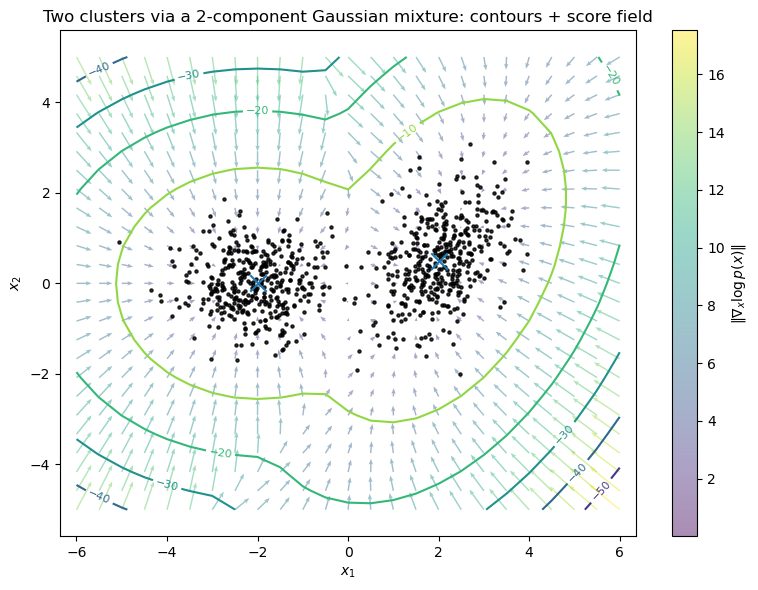

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# --- Two-cluster example: a 2-component Gaussian mixture ---
pis = np.array([0.5, 0.5])  # mixture weights

mus = np.array([
    [-2.0,  0.0],   # cluster 1 center
    [ 2.0,  0.5],   # cluster 2 center
])

Sigmas = np.array([
    [[0.6, 0.0],
     [0.0, 0.4]],   # cluster 1 covariance
    [[0.5, 0.25],
     [0.25, 0.8]],  # cluster 2 covariance (tilted)
])

Sigma_invs = np.linalg.inv(Sigmas)
logdets = np.log(np.linalg.det(Sigmas))

def log_gaussian_pdf(x, mu, Sigma_inv, logdet):
    d = x - mu
    quad = np.einsum('...i,ij,...j->...', d, Sigma_inv, d)
    return -0.5 * (2*np.log(2*np.pi) + logdet + quad)

def logsumexp(a, axis=-1):
    m = np.max(a, axis=axis, keepdims=True)
    return (m + np.log(np.sum(np.exp(a - m), axis=axis, keepdims=True))).squeeze(axis)

# Grid
x = np.linspace(-6, 6, 25)
y = np.linspace(-5, 5, 25)
X, Y = np.meshgrid(x, y)
grid = np.stack([X, Y], axis=-1)  # (ny, nx, 2)

# Component log-densities + log-weights
logps = []
for k in range(2):
    logps.append(np.log(pis[k]) + log_gaussian_pdf(grid, mus[k], Sigma_invs[k], logdets[k]))
logps = np.stack(logps, axis=-1)  # (ny,nx,2)

# Mixture log density
logp_mix = logsumexp(logps, axis=-1)  # (ny,nx)

# Responsibilities r_k(x) = pi_k N_k(x) / p(x)
resp = np.exp(logps - logp_mix[..., None])  # (ny,nx,2)

# Score for mixture: s(x) = sum_k r_k(x) * (-Sigma_k^{-1}(x-mu_k))
score = np.zeros_like(grid)
for k in range(2):
    d = grid - mus[k]
    s_k = -(d @ Sigma_invs[k].T)
    score += resp[..., k:k+1] * s_k

U, V = score[..., 0], score[..., 1]

# Sample points to visualize two clusters
N = 800
zs = np.random.choice(2, size=N, p=pis)
samples = np.vstack([
    np.random.multivariate_normal(mus[k], Sigmas[k], size=(zs == k).sum())
    for k in range(2)
])

plt.figure(figsize=(8, 6))

cs = plt.contour(X, Y, logp_mix, levels=6)
plt.clabel(cs, inline=True, fontsize=8)

# color by score magnitude
mag = np.sqrt(U**2 + V**2)

q = plt.quiver(
    X, Y, U, V, mag,              # <-- mag controls the color
    angles='xy', scale_units='xy', scale=20,
    cmap='viridis',               # colorful
    alpha=0.45,                   # lighter / more transparent
    width=0.0025,                 # thinner shafts
    headwidth=3.0, headlength=4.0, headaxislength=3.5,
    linewidths=0.4
)

plt.colorbar(q, label=r"$\|\nabla_x \log p(x)\|$")


plt.scatter(samples[:, 0], samples[:, 1], s=5, alpha=0.8, color='black')
plt.scatter(mus[:, 0], mus[:, 1], marker='x', s=140)

plt.title("Two clusters via a 2-component Gaussian mixture: contours + score field")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.axis("equal")
plt.tight_layout()
plt.show()